# Notebook 03 — Annotation Sampling

Draws a stratified sample from `cc_news_matched.parquet` and exports a CSV ready for hand-annotation in Google Sheets.

**Verbatim exclusion (Song et al. 2023):** Following the original paper, articles where the body text contains a quote that is identical (or near-identical) to the headline quote are excluded before sampling. Such cases are trivially detectable by string matching and add no signal for semantic modelling.

**Stratification variable:** `sim_bin` — similarity tercile (low / mid / high) computed *after* verbatim exclusion.  
Sampling within terciles ensures the annotation set covers the full difficulty spectrum rather than concentrating in the high-similarity mass.

**Columns exported** (what you see in Sheets):

| Column | Purpose |
|---|---|
| `article_id` | Row index for traceability |
| `domain` | News outlet |
| `date` | Publication date |
| `url` | Link to original article |
| `title` | Full headline |
| `headline_quote` | Quoted span extracted from headline |
| `best_body_sentence` | Best-matching body sentence |
| `prev_sentence` | Sentence before the match (context) |
| `next_sentence` | Sentence after the match (context) |
| `best_sim` | Cosine similarity score |
| `sim_margin` | Top-1 minus top-2 score (peakedness) |
| `sim_bin` | Similarity tercile label |
| `full_text` | Complete article body |
| `label` | **← annotator fills this in** |
| `notes` | **← annotator fills this in** |


In [2]:
import os
import pandas as pd
import numpy as np

# ── paths ────────────────────────────────────────────────────────────────────
DATA_DIR     = "data"                              # adjust if needed
MATCHED_PATH = os.path.join(DATA_DIR, "cc_news_matched.parquet")
OUTPUT_CSV   = os.path.join(DATA_DIR, "annotation_sample.csv")

# ── sampling parameters ───────────────────────────────────────────────────────
N_TOTAL   = 2000   # total articles to annotate
SEED      = 42    # reproducibility

# Proportion of N_TOTAL drawn from each similarity tercile
# Adjust these weights to oversample harder (low-sim) cases if desired
STRATA_WEIGHTS = {
    "low":  0.33,   # cosine < 33rd percentile
    "mid":  0.34,   # 33rd–66th percentile
    "high": 0.33,   # > 66th percentile
}

print(f"Loading {MATCHED_PATH} …")
df = pd.read_parquet(MATCHED_PATH)
print(f"Loaded {len(df):,} articles with columns: {df.columns.tolist()}")

Loading data/cc_news_matched.parquet …
Loaded 2,452 articles with columns: ['title', 'text', 'domain', 'date', 'url', 'title_quotes', 'body_quotes', 'n_title_quotes', 'n_body_quotes', 'has_body_quote', 'title_len', 'body_len', 'n_body_sentences', 'headline_quote', 'best_body_sentence', 'best_sim', 'best_sent_idx', 'prev_sentence', 'next_sentence', 'mean_sim', 'sim_margin']


## 1. Similarity Bins (Stratification Variable)

In [3]:
# ── Verbatim exclusion (following Song et al. 2023) ──────────────────────────
# Exclude articles where the headline quote appears near-verbatim in the body.
# These are trivially detectable by string matching and are uninformative for
# semantic annotation. Threshold of 0.97 captures near-identical matches
# (minor whitespace / punctuation differences) without over-excluding.
VERBATIM_THRESHOLD = 0.97

n_before = len(df)
df_filtered = df[df["best_sim"] < VERBATIM_THRESHOLD].copy()
df_excluded = df[df["best_sim"] >= VERBATIM_THRESHOLD].copy()
n_excluded = n_before - len(df_filtered)

print(f"Articles before exclusion : {n_before:,}")
print(f"Verbatim matches excluded  : {n_excluded:,}  (best_sim >= {VERBATIM_THRESHOLD})")
print(f"Articles remaining         : {len(df_filtered):,}")

# Print excluded cases for inspection
print("\n── Excluded near-verbatim cases ──────────────────────────────────────────")
for _, row in df_excluded[["headline_quote", "best_body_sentence", "best_sim"]].iterrows():
    print(f"\nSIM: {row['best_sim']:.4f}")
    print(f"HEADLINE : {row['headline_quote']}")
    print(f"BODY     : {row['best_body_sentence']}")

# Replace df so downstream cells use the filtered pool
df = df_filtered


Articles before exclusion : 2,452
Verbatim matches excluded  : 50  (best_sim >= 0.97)
Articles remaining         : 2,402

── Excluded near-verbatim cases ──────────────────────────────────────────

SIM: 0.9878
HEADLINE : I am rooting hard for you
BODY     : I am rooting hard for you.

SIM: 0.9878
HEADLINE : I am rooting hard for you
BODY     : I am rooting hard for you.

SIM: 0.9872
HEADLINE : Henry: Portrait of a Serial Killer
BODY     : 'Henry: Portrait of a Serial Killer'

SIM: 0.9726
HEADLINE : In my family, we just never talked about it.
BODY     : “In my family, we just never talked about it.”

SIM: 0.9762
HEADLINE : Materialica Design + Technology Award
BODY     : Materialica Design + Technology Award?

SIM: 0.9876
HEADLINE : Why I still support Duterte
BODY     : 'Why I still support Duterte'

SIM: 0.9908
HEADLINE : What to do about the rude woman and the man on the train sucking a chicken leg?
BODY     : ‘What to do about the rude woman and the man on the train sucking a chick

In [25]:
# Assign tercile labels based on best_sim distribution
terciles = df["best_sim"].quantile([1/3, 2/3]).values
print(f"Similarity tercile thresholds: {terciles[0]:.3f} | {terciles[1]:.3f}")

def assign_sim_bin(sim):
    if sim < terciles[0]:
        return "low"
    elif sim < terciles[1]:
        return "mid"
    else:
        return "high"

df["sim_bin"] = df["best_sim"].apply(assign_sim_bin)

print("\nArticles per tercile:")
print(df["sim_bin"].value_counts().sort_index())

Similarity tercile thresholds: 0.565 | 0.696

Articles per tercile:
sim_bin
high    801
low     801
mid     800
Name: count, dtype: int64


## 2. Stratified Sample

In [26]:
rng = np.random.default_rng(SEED)
frames = []

for stratum, weight in STRATA_WEIGHTS.items():
    n_draw  = round(N_TOTAL * weight)
    pool    = df[df["sim_bin"] == stratum]
    n_draw  = min(n_draw, len(pool))   # safety cap
    sample  = pool.sample(n=n_draw, random_state=SEED)
    frames.append(sample)
    print(f"  {stratum:4s} → drew {n_draw} from {len(pool):,} candidates")

sample_df = pd.concat(frames).sample(frac=1, random_state=SEED)  # shuffle
sample_df = sample_df.reset_index().rename(columns={"index": "article_id"})

print(f"\nTotal sample size: {len(sample_df)}")

  low  → drew 660 from 801 candidates
  mid  → drew 680 from 800 candidates
  high → drew 660 from 801 candidates

Total sample size: 2000


## 3. Inspect a Few Rows

In [27]:
display_cols = [
    "article_id", "sim_bin", "best_sim",
    "headline_quote", "best_body_sentence",
]
sample_df[display_cols].head(10)

,article_id,sim_bin,best_sim,headline_quote,best_body_sentence
0,701,high,0.721711,The Art of Found Objects,"For an art book about artists, many of whom ar..."
1,795,low,0.260817,personal matter at home,The Ottawa Senators have given goaltender Crai...
2,1976,mid,0.577846,could herald new era of capitalism,Mr Owen said that he felt that despite the unc...
3,1504,mid,0.653806,demand removal of CEO,The protesters say it is the CEO who should be...
4,1920,mid,0.591051,"I was too smooth, before time rolled its evil ...","“I was too smooth,” he says and laughs, “befor..."
5,866,mid,0.617504,Keeping Up With the Kardashians,'Keeping Up With the Kardashians' resumes prod...
6,737,mid,0.671125,I want to ride my bicycle,But I knew that the potential benefits of havi...
7,2246,high,0.834804,I want to have LeBron James come and visit me,“I just want to have LeBron James come and vis...
8,1284,low,0.452810,Stick to the day job,"'Stick to the day job', bemused fishermen tell..."
9,1723,mid,0.671617,Confidence is extremely attractive in all sens...,Having confidence in the workplace and in life...


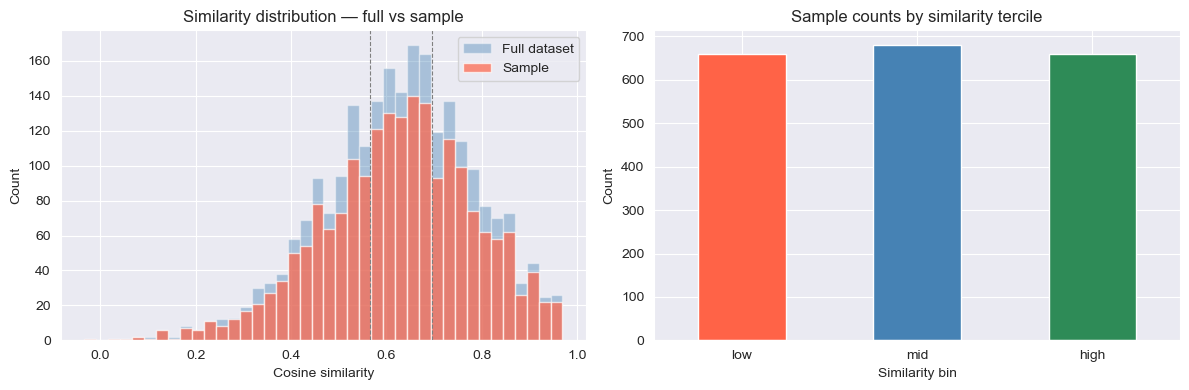

Plot saved.


In [28]:
# Quick distribution sanity check
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["best_sim"], bins=40, alpha=0.4, label="Full dataset", color="steelblue")
axes[0].hist(sample_df["best_sim"], bins=40, alpha=0.7, label="Sample", color="tomato")
axes[0].axvline(terciles[0], color="grey", linestyle="--", linewidth=0.8)
axes[0].axvline(terciles[1], color="grey", linestyle="--", linewidth=0.8)
axes[0].set_xlabel("Cosine similarity")
axes[0].set_ylabel("Count")
axes[0].set_title("Similarity distribution — full vs sample")
axes[0].legend()

sample_df["sim_bin"].value_counts().reindex(["low","mid","high"]).plot(
    kind="bar", ax=axes[1], color=["tomato","steelblue","seagreen"], edgecolor="white"
)
axes[1].set_title("Sample counts by similarity tercile")
axes[1].set_xlabel("Similarity bin")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "annotation_sample_distribution.png"), dpi=150)
plt.show()
print("Plot saved.")

## 4. Export to CSV

Columns are ordered for comfortable reading in Sheets:
- The two empty columns (`label`, `notes`) come last so the annotator can fill them in without scrolling.
- `full_text` is included but can be hidden in Sheets to reduce clutter — it's there for reference when the headline/body context is ambiguous.

In [29]:
# Build export dataframe
# Rename 'text' to 'full_text' for clarity in Sheets
if "text" in sample_df.columns:
    sample_df = sample_df.rename(columns={"text": "full_text"})

EXPORT_COLS = [
    # ── identifiers ──────────────────────────────────────────────
    "article_id",
    "domain",
    "date",
    "url",
    # ── annotation targets ───────────────────────────────────────
    "title",
    "headline_quote",
    "prev_sentence",
    "best_body_sentence",
    "next_sentence",
    # ── model signals ────────────────────────────────────────────
    "best_sim",
    "sim_margin",
    "sim_bin",
    # ── full text for reference ──────────────────────────────────
    "full_text",
    # ── annotator fills these in ─────────────────────────────────
    "label",
    "notes",
]

# Add empty annotator columns if not present
for col in ["label", "notes"]:
    if col not in sample_df.columns:
        sample_df[col] = ""

# Keep only the columns that exist in the dataframe
available = [c for c in EXPORT_COLS if c in sample_df.columns]
missing   = [c for c in EXPORT_COLS if c not in sample_df.columns]
if missing:
    print(f"⚠ Columns not found (skipped): {missing}")

export_df = sample_df[available].copy()

# Round numeric columns for readability in Sheets
for col in ["best_sim", "sim_margin"]:
    if col in export_df.columns:
        export_df[col] = export_df[col].round(4)

export_df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")  # utf-8-sig for Excel/Sheets
print(f"Saved {len(export_df)} rows → {OUTPUT_CSV}")
print(f"Columns: {export_df.columns.tolist()}")

Saved 2000 rows → data/annotation_sample.csv
Columns: ['article_id', 'domain', 'date', 'url', 'title', 'headline_quote', 'prev_sentence', 'best_body_sentence', 'next_sentence', 'best_sim', 'sim_margin', 'sim_bin', 'full_text', 'label', 'notes']


## 5. Optional: Domain-Stratified Variant

If you also want to ensure domain diversity in the sample (e.g. at most *k* articles per domain), run this cell **instead of** section 2.
The result is then passed through sections 3 and 4 as before.

In [30]:
# ── parameters ─────────────────────────────────────────────────────────────
MAX_PER_DOMAIN = 15    # cap per domain

assert 'sim_bin' in df.columns, 'Run section 1 first to assign sim_bin'

# Flatten index; keep article_id as a plain column before any reshuffling
df_flat = df.reset_index(drop=True).copy()
df_flat['article_id'] = df_flat.index

# Explicit loop instead of groupby — avoids pandas >=2.0 index absorption
capped_frames = []
for _domain in df_flat['domain'].unique():
    grp = df_flat[df_flat['domain'] == _domain]
    capped_frames.append(grp.sample(min(len(grp), MAX_PER_DOMAIN), random_state=SEED))
domain_capped = pd.concat(capped_frames, ignore_index=True)

print(f'After domain cap: {len(domain_capped):,} rows across {domain_capped["domain"].nunique()} domains')

# Stratify by sim_bin within the capped pool
frames_domain = []
for stratum, weight in STRATA_WEIGHTS.items():
    n_draw = round(N_TOTAL * weight)
    pool   = domain_capped[domain_capped['sim_bin'] == stratum]
    n_draw = min(n_draw, len(pool))
    frames_domain.append(pool.sample(n=n_draw, random_state=SEED))
    print(f'  {stratum:4s} drew {n_draw} from {len(pool):,} candidates')

sample_domain_df = (
    pd.concat(frames_domain, ignore_index=True)
      .sample(frac=1, random_state=SEED)
      .reset_index(drop=True)
)

print(f'\nDomain-stratified sample: {len(sample_domain_df)} articles')
print(f'Unique domains: {sample_domain_df["domain"].nunique()}')
sample_domain_df['sim_bin'].value_counts().reindex(['low','mid','high'])


After domain cap: 1,623 rows across 356 domains
  low  drew 525 from 525 candidates
  mid  drew 542 from 542 candidates
  high drew 556 from 556 candidates

Domain-stratified sample: 1623 articles
Unique domains: 356


sim_bin
low     525
mid     542
high    556
Name: count, dtype: int64

## Annotation Label Guide

Use these values in the `label` column:

| Label | Name | Criterion |
|---|---|---|
| `0` | **Modified** | Headline quote changes wording or form but the speaker's core claim reads the same — corrects grammar, replaces pronouns with names, removes filler, substitutes synonyms |
| `1` | **Contextomized** | Headline quote changes the speaker's apparent position, claim, or intent — truncates to reverse meaning, omits a key qualifier, or transplants words into a different argument |
| `?` | **Unclear** | Full text insufficient to judge, or quote sourced externally and not present in body |

**Decision heuristic:** Read the headline quote, then read `prev_sentence` + `best_body_sentence` + `next_sentence`. Ask: *Would a reasonable reader attribute a different claim to the speaker based on the headline quote alone?* If yes → `1`. If no → `0`.

**Boundary cases to watch:**
- Headline quote *combines* two separate body quotes into one → `0` if the combined meaning is faithful (Song et al. note this as a common false-positive pattern)
- Omitted text was only filler/hedging ("I think", "perhaps") with no change to core claim → `0`
- Omitted text was the speaker's main qualifier, reversing their point → `1`

Use the `notes` column for brief reasoning, especially for `?` cases or borderline `1`s.

**Tip for Sheets:** Freeze columns A–L, hide column M (`full_text`) by default, and use data validation on the `label` column to restrict to `0`, `1`, `?`.


## Benchmark Dataset: Korean Contextomized Quote Corpus

In addition to the English annotation sample created above, we include a Korean benchmark dataset stored as `contextomized_quote.pkl`. This dataset contains headline quotes, body quotes, full headlines, article bodies, source URLs, and binary labels indicating whether the headline quote is contextomized.

The dataset is intended for benchmarking and transfer evaluation rather than for direct inclusion in the English sampling pipeline above. It provides a labeled test bed for measuring how well methods generalize to a different language and news domain.

Columns:
- `headlinequote`: quoted span extracted from the headline
- `bodyquotes`: quoted spans extracted from the article body
- `headline`: original headline text
- `body`: full article body text
- `url`: source article URL
- `label`: binary contextomy label

In [31]:
benchmark_df = pd.read_pickle("data/contextomized_quote.pkl")
print("Benchmark shape:", benchmark_df.shape)
print("Columns:", benchmark_df.columns.tolist())
benchmark_df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/contextomized_quote.pkl'

tes test test